<a href="https://colab.research.google.com/github/Shikaaaaaaaaa/Ahmedfathy.com/blob/main/California_Housing_My_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
housing = pd.read_csv('/content/housing.csv')

## intial Exploratory  
we figure that we have all float instead of only 1 category feature and
we have 20640 row for every feature except total_bedrooms

In [48]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [49]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [50]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


So we have 207 null values on Total_Bedrooms

In [51]:
housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [52]:
housing.duplicated().sum()


np.int64(0)

we know now that we have 5 places inside Ocean Proximity

In [53]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## Visualization
it seems like there's alot of features has Skweed distribution and median income is only between 0-5 or maybe 6 kinda weird

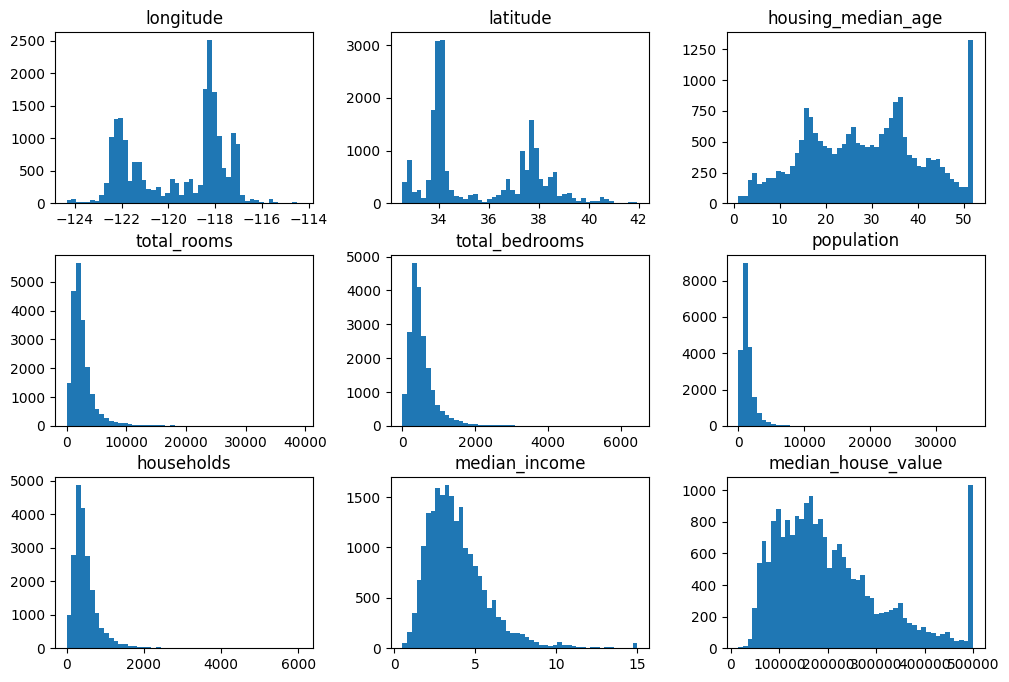

In [54]:
housing.hist(figsize=(12,8),grid = False , bins=50)
plt.show()

I used Alpha 0.3 to see if there's a locations has a high density than other or not so i think now location is important

Text(0.5, 1.0, 'Longitude vs latitude')

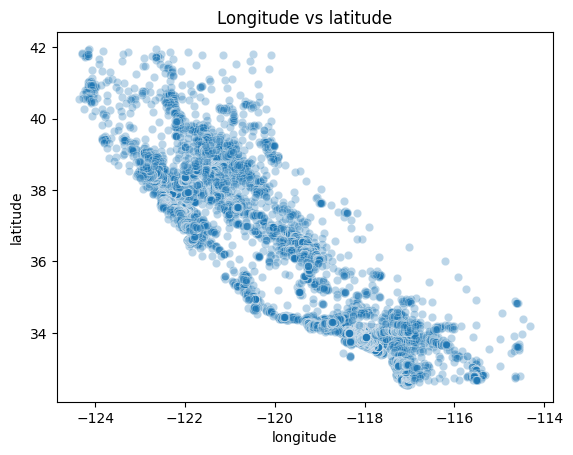

In [55]:
sns.scatterplot(x='longitude',y='latitude',data=housing,alpha=0.3)
plt.title('Longitude vs latitude')

we got approval that median income is almost capped between 0-6

Text(0.5, 1.0, 'median_income vs median_house_value')

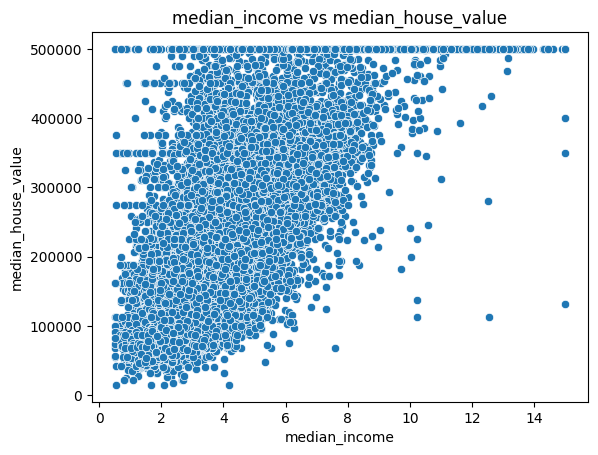

In [56]:
sns.scatterplot(x='median_income',y='median_house_value',data=housing)
plt.title('median_income vs median_house_value')

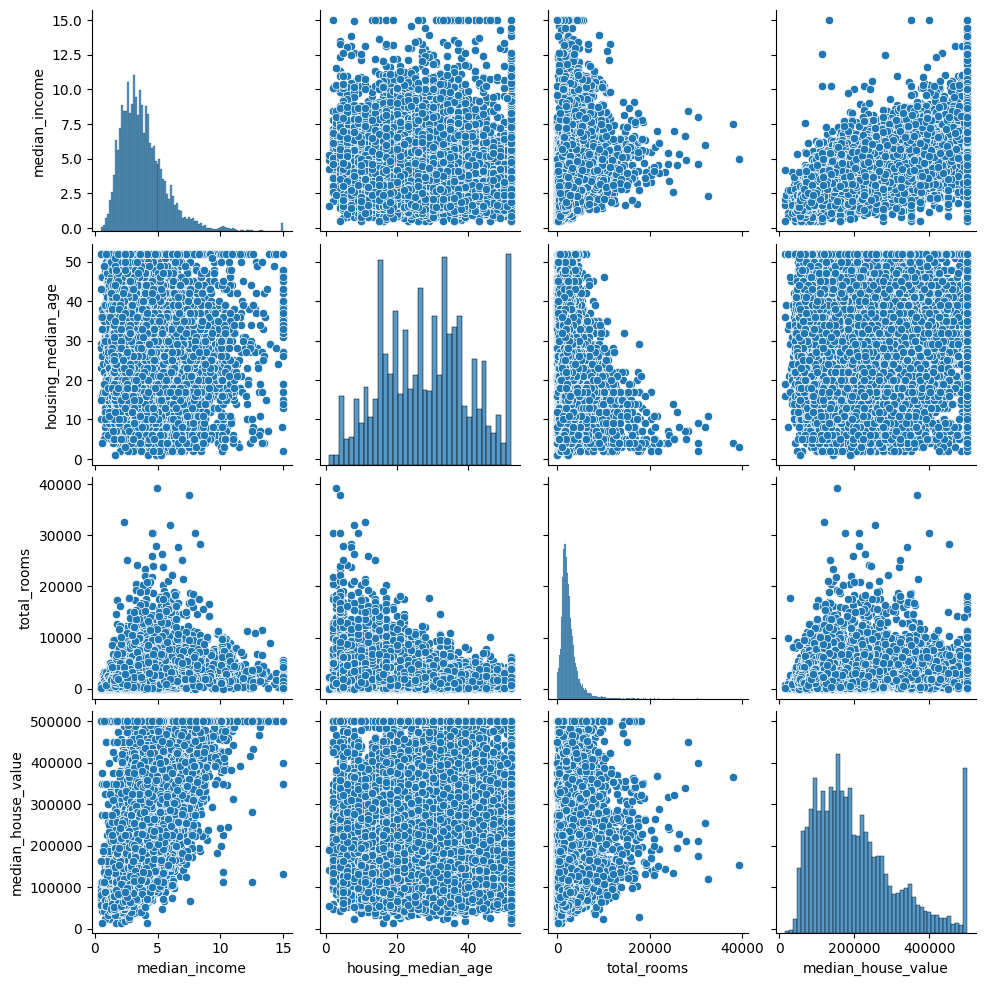

In [57]:
sns.pairplot(housing[[
     'median_income',
    'housing_median_age',
    'total_rooms',
    'median_house_value'
]]

)

## Correlation

median income is the most correlated feature

In [58]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix = corr_matrix['median_house_value'].sort_values(ascending=False)
corr_matrix

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


## Split
i will try to make sure that median income will be splitted well on the training and testing
we used stratified split to make sure that all levels of median income got shared fairly on the test and train

In [59]:
from sklearn.model_selection import StratifiedShuffleSplit
housing['income_cat'] = pd.cut(housing['median_income'],
                               bins = [0,1.5,3,4.5,6,np.inf]
                               ,labels = [1,2,3,4,5]
                               )

In [60]:
split = StratifiedShuffleSplit(n_splits = 1 , test_size = 0.2,random_state= 1 )

In [61]:
for train_index , test_index in split.split(housing,housing['income_cat']):
  train_set = housing.iloc[train_index]
  test_set = housing.iloc[test_index]
for s in(train_set,test_set):
  s.drop('income_cat', axis=1, inplace=True)

/tmp/ipykernel_16519/3251236805.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s.drop('income_cat', axis=1, inplace=True)
/tmp/ipykernel_16519/3251236805.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s.drop('income_cat', axis=1, inplace=True)


In [62]:
housing = train_set.drop('median_house_value',axis = 1)
housing_labels = train_set["median_house_value"].copy()



```
# This is formatted as code
```

## Preprocessing
In preprocessing, I need to handle missing values, scale numerical features, and encode the categorical feature. To do that, I create separate pipelines for numerical and categorical columns, then combine them using a ColumnTransformer.


In [75]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [76]:
housing_num = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income']
housing_cat = ['ocean_proximity']

In [83]:
from sklearn import pipeline
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

In [84]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

Here how can we merge them

In [87]:
from sklearn.compose import ColumnTransformer

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, housing_num),
    ('cat', cat_pipeline, housing_cat)
])

In [88]:
full_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder())]),
                                 ['ocean_proximity'])])

In [100]:
housing_prepared = full_pipeline.fit_transform(housing)


In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [107]:
reg_model = make_pipeline(full_pipeline,LinearRegression())
reg_model.fit(housing,housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['ocean_proximity'])])),
                ('linearregression', LinearRegression())])

In [108]:
prediction = reg_model.predict(housing)

In [109]:
prediction[:5].round(2)

array([115506.88, 378637.41, 629820.39, 318060.41,  38184.99])

In [110]:
housing_labels[:5].values

array([130300., 432600., 500001., 347700.,  62200.])

In [115]:
print('MSE:',mean_squared_error(prediction,housing_labels))
print('MAE:',mean_absolute_error(prediction,housing_labels))
print('RMSE:',root_mean_squared_error(prediction,housing_labels))
print('R2:',r2_score(prediction,housing_labels))

MSE: 4804977754.362155
MAE: 50304.63544463839
RMSE: 69317.94684179671
R2: 0.44222388504681576


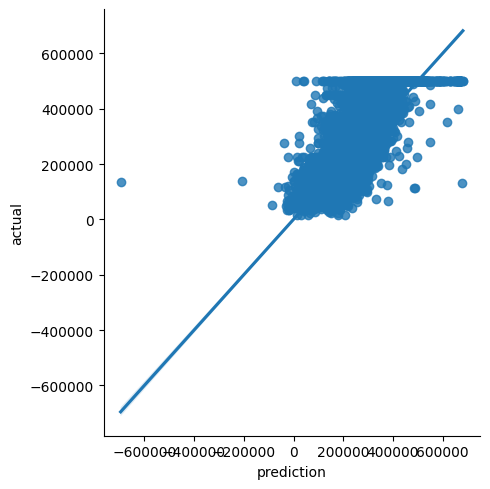

In [127]:
plot_df = pd.DataFrame({
    "prediction": prediction,
    "actual": housing_labels
})

sns.lmplot(x="prediction", y="actual", data=plot_df)
plt.show()

In [129]:
from sklearn.ensemble import RandomForestRegressor
rfr = make_pipeline(full_pipeline,RandomForestRegressor(n_estimators=100,random_state=42))
rfr.fit(housing,housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['ocean_proximity'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [130]:
prediction = rfr.predict(housing)

In [132]:
prediction[:5]

array([127365.  , 432590.04, 498549.94, 359371.  ,  65638.  ])

In [133]:
housing_labels[:5].values

array([130300., 432600., 500001., 347700.,  62200.])

In [134]:
print('MSE:',mean_squared_error(prediction,housing_labels))
print('MAE:',mean_absolute_error(prediction,housing_labels))
print('RMSE:',root_mean_squared_error(prediction,housing_labels))
print('R2:',r2_score(prediction,housing_labels))

MSE: 339574641.7577139
MAE: 11846.653818435077
RMSE: 18427.551160089446
R2: 0.971378881301004


In [135]:
from sklearn.tree import DecisionTreeRegressor
dtr = make_pipeline(full_pipeline,DecisionTreeRegressor(random_state=42))
dtr.fit(housing,housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['ocean_proximity'])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [136]:
prediction = dtr.predict(housing)

In [137]:
prediction[:5]

array([130300., 432600., 500001., 347700.,  62200.])

In [138]:
housing_labels[:5].values

array([130300., 432600., 500001., 347700.,  62200.])